In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../../")

from scipy.io import loadmat
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

# import ptitprince as ptit
import seaborn as sns
from scipy.io import savemat
import pickle as pkl
# import pingouin as pg
from scipy.stats import friedmanchisquare

In [86]:
# !pip install seaborn==0.2.6

In [87]:
##session-1 data of MEG
data1=loadmat("../../Database_PWelch_AvgTrials_MI_Baseline_RS1_19Subjects_MEG_Sess1.mat")
fvec=np.squeeze(data1["Freqs"])[3:30]

df=pd.read_excel('../../ListROIs_DK.xlsx')

In [88]:
##MEG-modeled data
x_mi_all={}
x_base_all={}
x_rest_all={}

for num in range(1, 5):
    x_mi_all[num]=np.zeros((68, 10, 19))
    x_base_all[num]=np.zeros((68, 10, 19))
    x_rest_all[num]=np.zeros((68, 10, 19))
    
    for i in range(19):
        mi_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/mi_allsubs_f/mi_nostim_mse_db_fvec330_{i}.p'
        with open(mi_fname, 'rb') as f:
            x_mi_all[num][:,:,i]=np.array(pkl.load(f))

        base_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/baseline_allsubs_f/baseline_nostim_mse_db_fvec330_{i}.p'
        with open(base_fname, 'rb') as f:
            x_base_all[num][:,:,i] = np.array(pkl.load(f))
        
        rest_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/rs1_allsubs_f0/rs1_nostim_mse_db_fvec330_{i}.p'
        with open(rest_fname, 'rb') as f:
            x_rest_all[num][:,:,i]=np.array(pkl.load(f))


In [89]:
#lIST of all the regions name and their indices
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

In [90]:
all_regions_dict=dict(zip(all_regions, all_regions_idx))
all_regions_dict

{'bankssts L': 0,
 'bankssts R': 1,
 'caudalanteriorcingulate L': 2,
 'caudalanteriorcingulate R': 3,
 'caudalmiddlefrontal L': 4,
 'caudalmiddlefrontal R': 5,
 'cuneus L': 6,
 'cuneus R': 7,
 'entorhinal L': 8,
 'entorhinal R': 9,
 'frontalpole L': 10,
 'frontalpole R': 11,
 'fusiform L': 12,
 'fusiform R': 13,
 'inferiorparietal L': 14,
 'inferiorparietal R': 15,
 'inferiortemporal L': 16,
 'inferiortemporal R': 17,
 'insula L': 18,
 'insula R': 19,
 'isthmuscingulate L': 20,
 'isthmuscingulate R': 21,
 'lateraloccipital L': 22,
 'lateraloccipital R': 23,
 'lateralorbitofrontal L': 24,
 'lateralorbitofrontal R': 25,
 'lingual L': 26,
 'lingual R': 27,
 'medialorbitofrontal L': 28,
 'medialorbitofrontal R': 29,
 'middletemporal L': 30,
 'middletemporal R': 31,
 'paracentral L': 32,
 'paracentral R': 33,
 'parahippocampal L': 34,
 'parahippocampal R': 35,
 'parsopercularis L': 36,
 'parsopercularis R': 37,
 'parsorbitalis L': 38,
 'parsorbitalis R': 39,
 'parstriangularis L': 40,
 'par

In [91]:
motor_regions=['paracentral L', 'paracentral R', 'postcentral L', 'postcentral R', 'precentral L', 'precentral R']
#Find the indices of the motor regions
motor_regions_idx=[]
for r in motor_regions:
    motor_regions_idx.append(all_regions.index(r))

## motor region index and names
motor_region_dict={}
for i in range(len(motor_regions)):
    motor_region_dict[motor_regions_idx[i]]=motor_regions[i]    
motor_region_dict

{32: 'paracentral L',
 33: 'paracentral R',
 44: 'postcentral L',
 45: 'postcentral R',
 48: 'precentral L',
 49: 'precentral R'}

In [92]:
##session 4, significant regions for meg
gii_regions=['postcentral R', 'transversetemporal L']
# tau_e_regions=['bankssts L', 'cuneus L', 'entorhinal L', 'inferiorparietal L', 'inferiorparietal R', 'isthmuscingulate R', 'paracentral L', 'paracentral R', 
#  'pericalcarine L', 'postcentral L', 'postcentral R', 'posteriorcingulate L', 'posteriorcingulate R', 'precentral R', 'precuneus L', 'precuneus R', 
#  'supramarginal L', 'supramarginal R', 'transversetemporal L']

##Significant left motor areas for taue 
tau_e_regions=['paracentral L', 'postcentral L']



In [93]:
##session 4, significant(pFDR<0.05) regions for the respective parameters in MEG and their indices
gii_idx=[]
tau_e_idx=[]
for idx, region in enumerate(all_regions):
    if region in gii_regions:
        gii_idx.append(idx)
for idx, region in enumerate(all_regions):
    if region in tau_e_regions:
        tau_e_idx.append(idx)


print(gii_idx, tau_e_idx)

[45, 66] [32, 44]


In [94]:
x_mi_all[4].shape, x_mi_all[1][45, 1, :]

((68, 10, 19),
 array([1.42758816e-01, 1.70322520e+00, 1.42995211e+00, 3.57027831e-01,
        1.37518173e+00, 8.06943373e-01, 1.89319634e+00, 1.91575523e-01,
        2.23968430e-01, 1.09683856e+00, 8.58429199e-01, 1.70533414e+00,
        2.06992230e-02, 1.51575756e+00, 1.19831868e-03, 2.07822212e-02,
        1.48563758e+00, 1.55551995e+00, 1.90000000e+00]))

In [95]:
for i in range(1,5):
    x_mi_all[i][45, 1, :], x_rest_all[i][45,1,:]

## Friedman test on significant regions

In [96]:
####Friedman test for tau_e
RED_TEXT = "\033[91m"
RESET_TEXT = "\033[0m"

mi_pvalues = []
rest_pvalues=[]
for num in tau_e_idx:
    mi_data = []
    rest_data = []
    for sess in range(1, 5): 
        mi_values = x_mi_all[sess][num, 2, :]  
        rest_values = x_rest_all[sess][num, 2, :]  

        mi_data.append(mi_values)
        rest_data.append(rest_values)

    mi_data = np.array(mi_data)  #(4, 19)
    rest_data = np.array(rest_data) #(4, 19)

    friedman_mi = friedmanchisquare(mi_data[0], mi_data[1], mi_data[2], mi_data[3])
    mi_pvalues.append(friedman_mi.pvalue)
    friedman_rest = friedmanchisquare(rest_data[0], rest_data[1], rest_data[2], rest_data[3])
    rest_pvalues.append(friedman_rest.pvalue)


In [97]:
mi_pvalues, rest_pvalues

([0.04524437704665326, 0.48114905564805954],
 [0.5625822476058528, 0.33653356884306984])

In [98]:
# # Bonferroni correction on the two p-value list of mi
adjusted_p_values = [min(1, p*len(mi_pvalues)) for p in mi_pvalues]
print("Bonferroni-adjusted p-values:", adjusted_p_values)

# fdr_corr= fdrcorrection(mi_pvalues)[1]
# fdr_corr

Bonferroni-adjusted p-values: [0.09048875409330652, 0.9622981112961191]


### group level parameters values distribution using BOX/Rain cloud plots

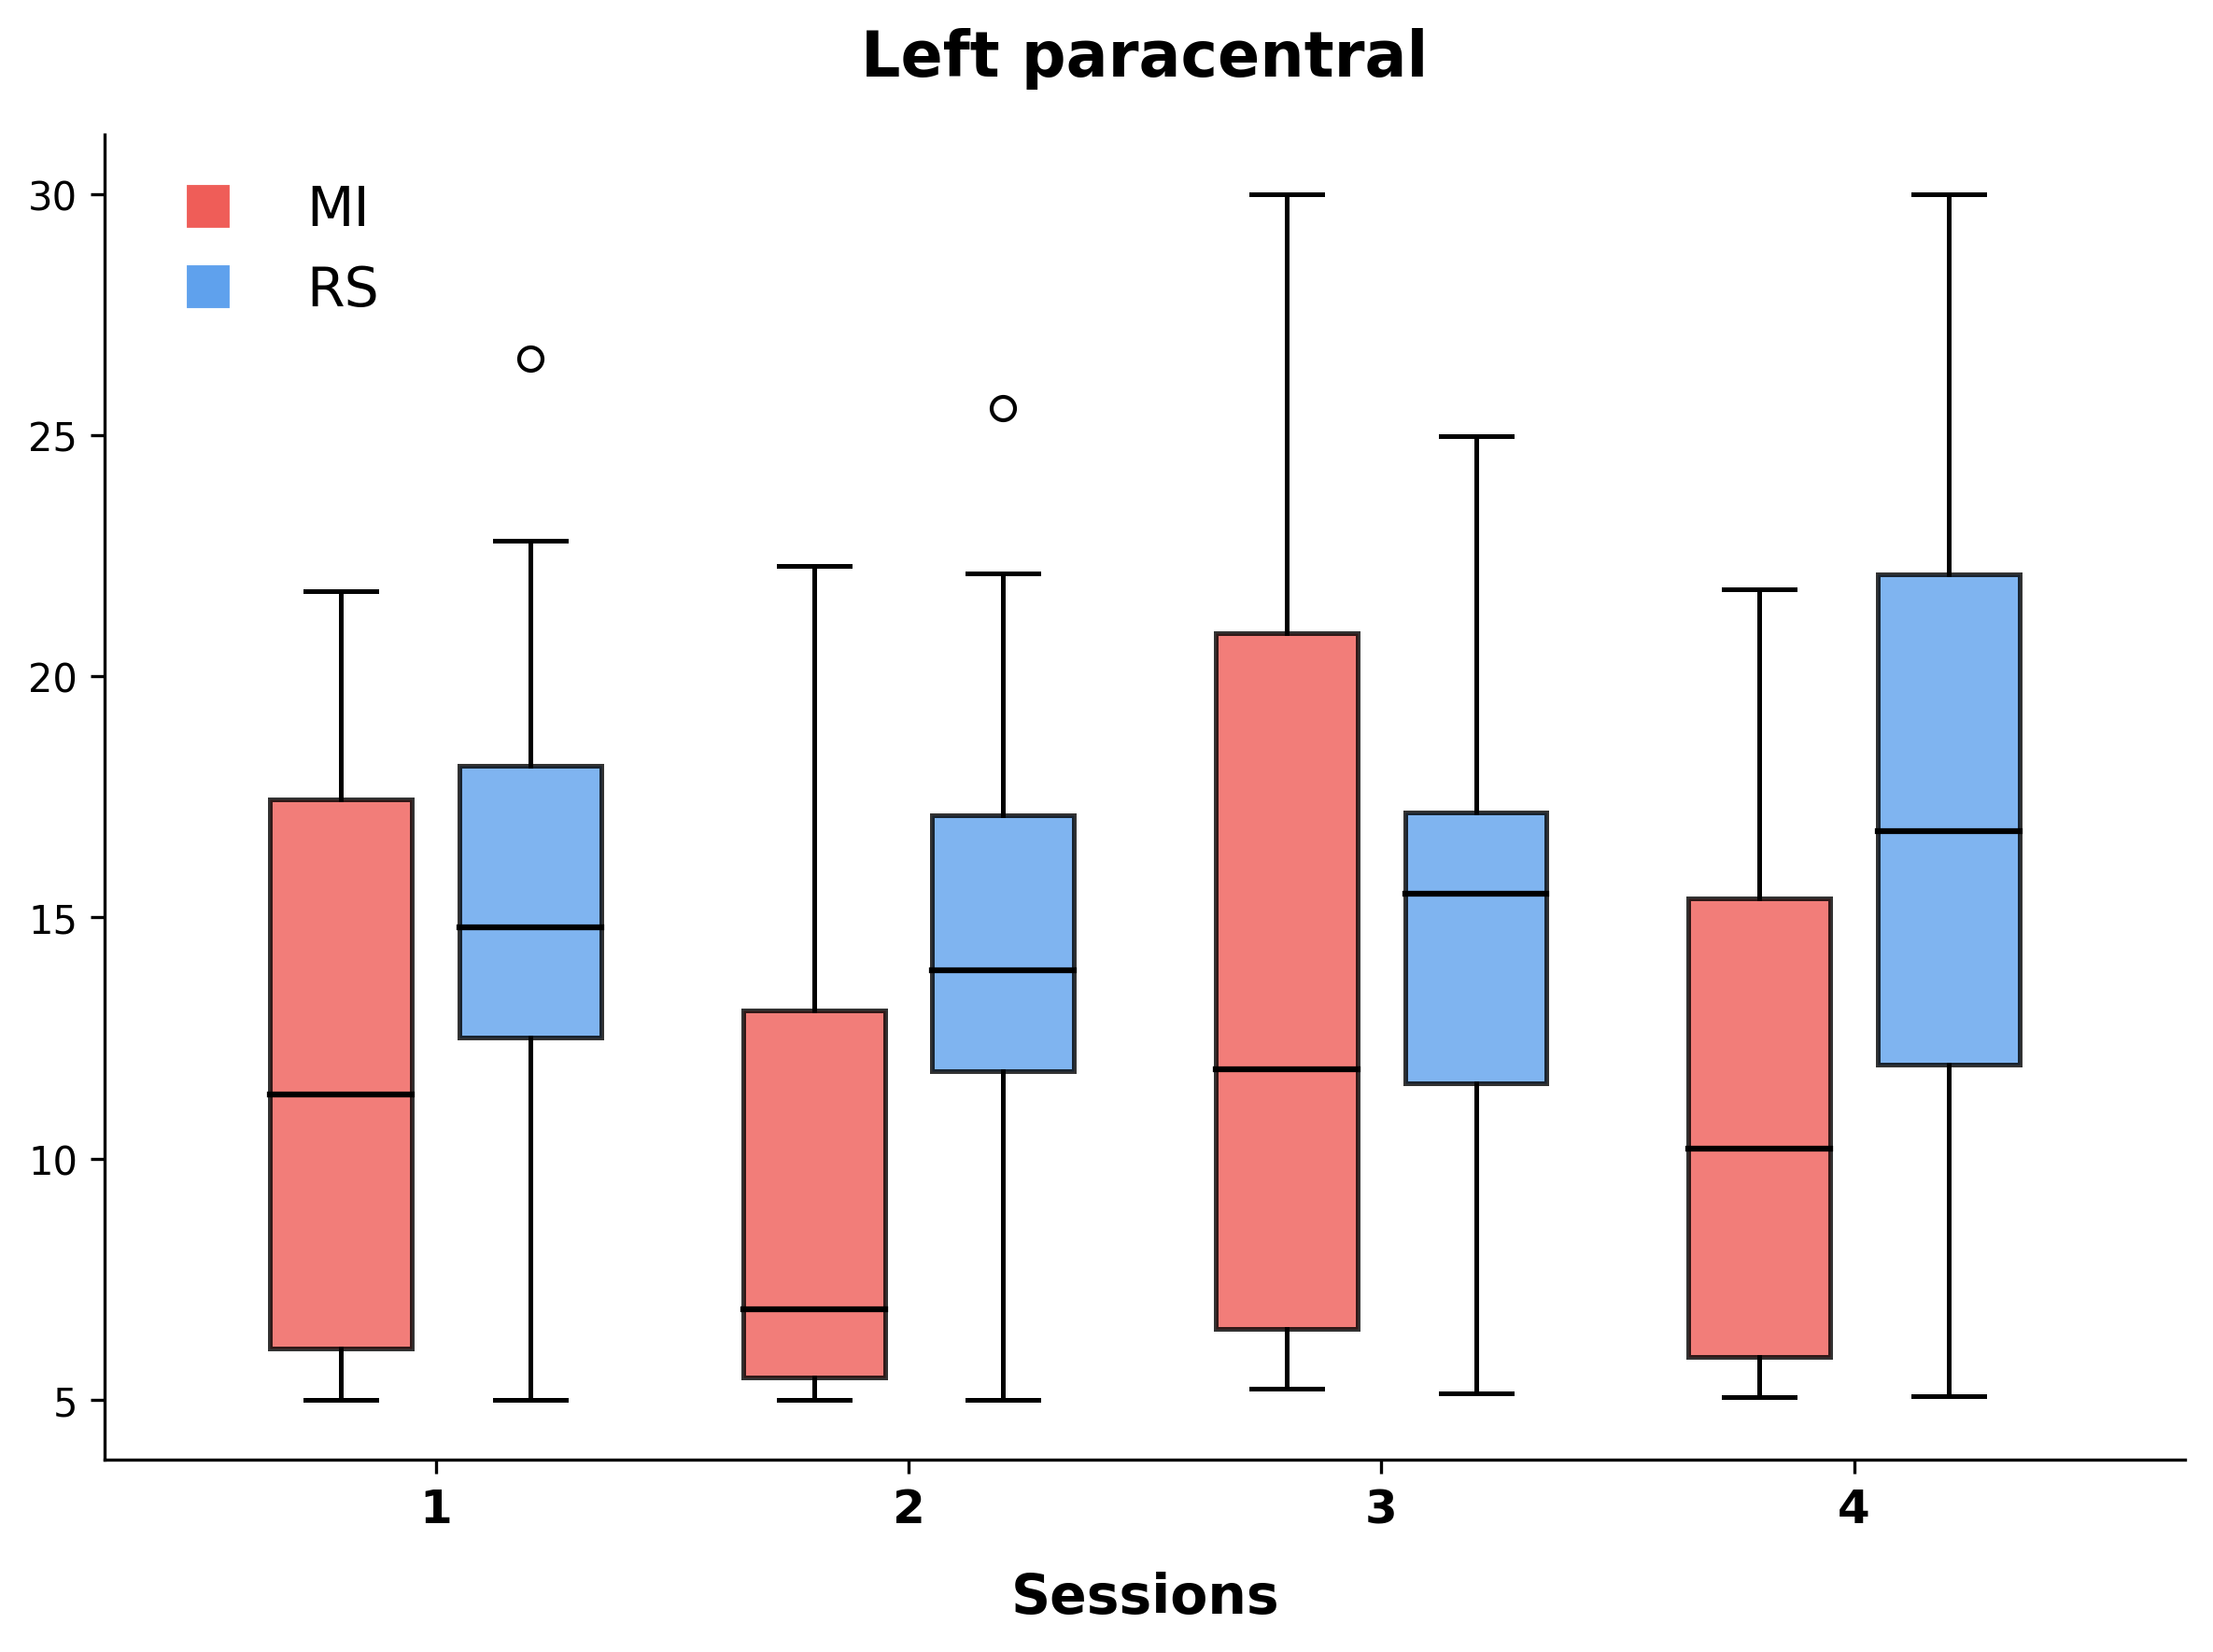

In [102]:
## For left paracentral region
sessions = range(1, 5)
mi_values = [x_mi_all[i][32, 2, :] for i in sessions]
rest_values = [x_rest_all[i][32, 2, :] for i in sessions]

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

colors = ['#EF5D58','#5FA1ED'] 
positions = []
data = []
box_colors = []

for i, session in enumerate(sessions):
    positions.append(i - 0.2)  
    data.append(mi_values[i])
    box_colors.append(colors[0])

    positions.append(i + 0.2)  
    data.append(rest_values[i])
    box_colors.append(colors[1])

box = ax.boxplot(
    data, positions=positions, patch_artist=True, widths=0.3,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.2},
    capprops={'linewidth': 1.2},
    boxprops={'linewidth': 1.2}
)


for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)  

ax.set_title(f"Left {all_regions[32][:-2]}", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Sessions", fontsize=14, fontweight="bold", labelpad=10)
# ax.set_ylabel("Metric Value", fontsize=14, fontweight="bold", labelpad=10)


ax.set_xticks(range(len(sessions)))
ax.set_xticklabels([str(s) for s in sessions], fontsize=12, fontweight="bold")

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [
    plt.Line2D([0], [0], marker='s', color='w', markersize=12, markerfacecolor=colors[0], label="MI"),
    plt.Line2D([0], [0], marker='s', color='w', markersize=12, markerfacecolor=colors[1], label="RS")
]
ax.legend(handles=legend_patches, frameon=False, loc="upper left", fontsize=14)
plt.tight_layout()
plt.show()


## Raincloud plot

In [103]:
import ptitprince as pt

In [104]:
sessions = range(1, 5)
data_dict = { 'Session':[],'taue': [],'Condition': []}

for i, session in enumerate(sessions):
    data_dict['Session'] += [session] * len(mi_values[i]) + [session] * len(rest_values[i])
    data_dict['taue'] += list(mi_values[i]) + list(rest_values[i])
    data_dict['Condition'] += ['MI'] * len(mi_values[i]) + ['Rest'] * len(rest_values[i])

df5 = pd.DataFrame(data_dict)


## Figure for paper

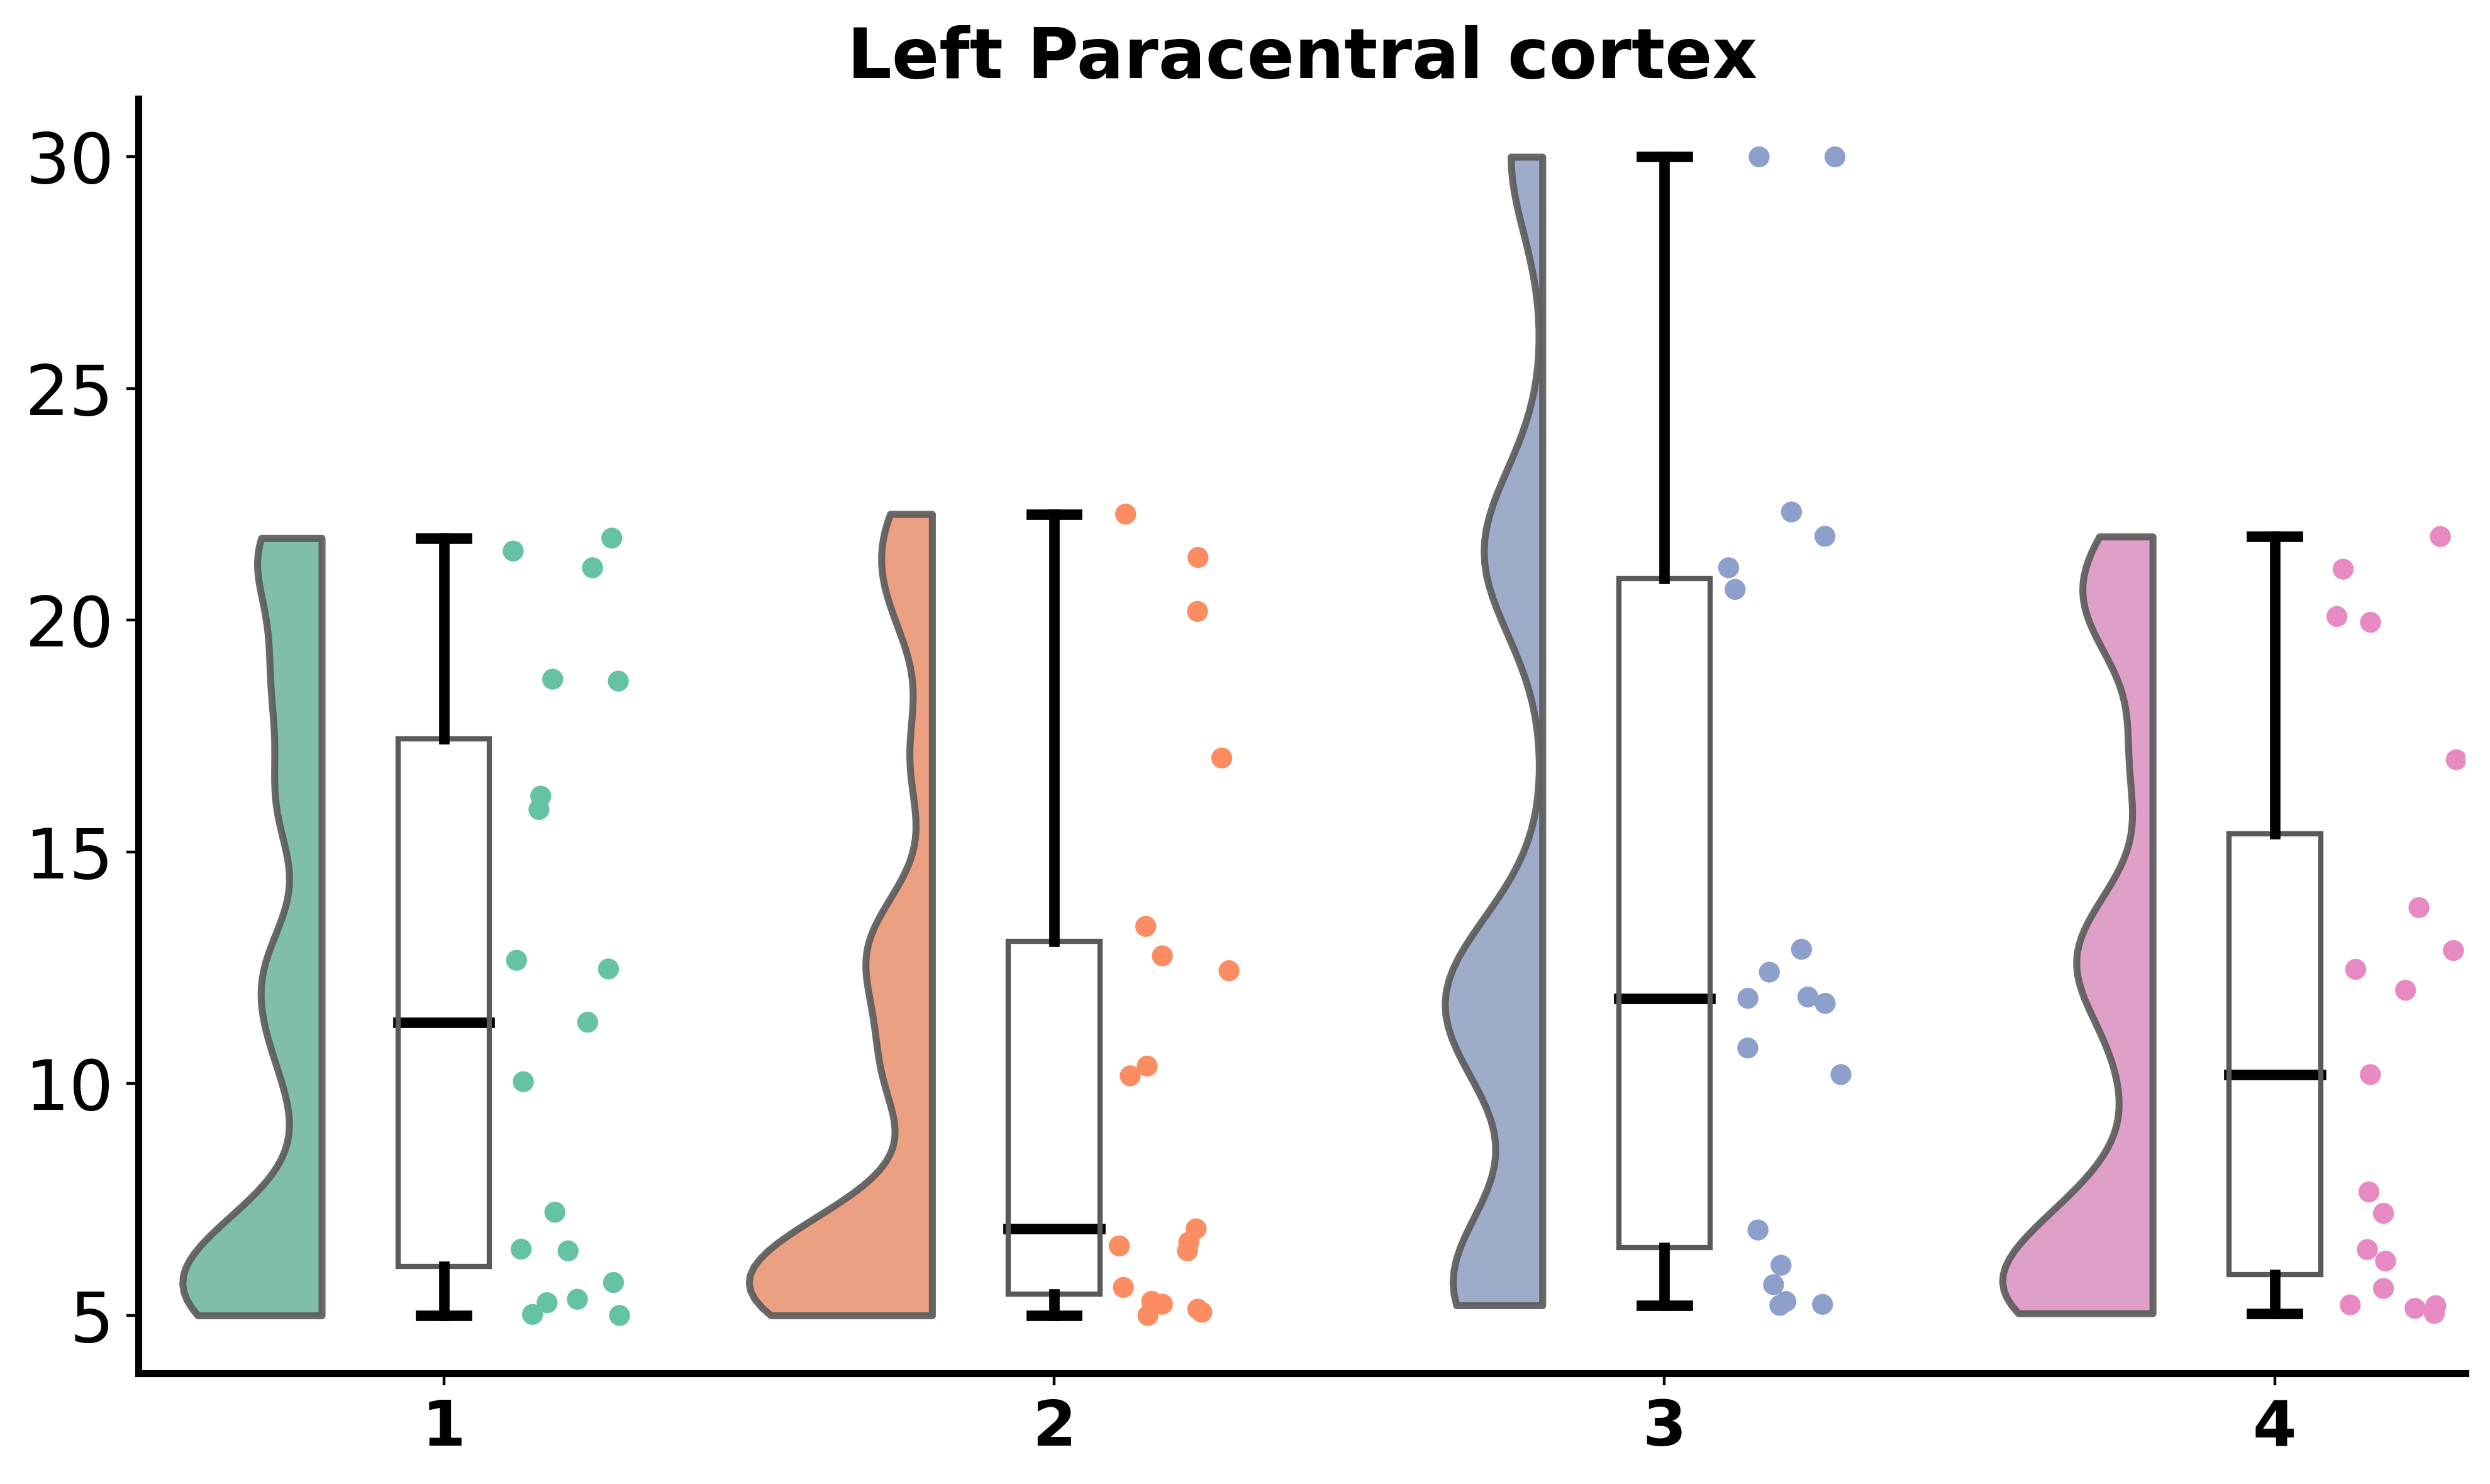

In [105]:
## Left Paracentral lobule-for MI condition
df_mi = df5[df5["Condition"] == "MI"]

plt.figure(figsize=(10, 6), dpi=400)
#increase size of y axis labels
ax = pt.RainCloud(x="Session", y="taue", data=df_mi,
                  palette="Set2", bw=.2, width_viol=.6, ax=None,
                  orient="v", move=0.2, alpha=0.9, point_size=6, linewidth=2)

ax.tick_params(
    axis="y",
    labelsize=20,
)

for artist in ax.artists:
    artist.set_edgecolor("black") 
    artist.set_linewidth(2)

for line in ax.lines:
    line.set_color("black")  
    line.set_linewidth(3)

plt.title("Left Paracentral cortex", fontweight='bold', fontsize=20)
plt.grid(False)
plt.xlabel("", fontsize=16)
plt.ylabel("", fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.set_xticklabels([str(s) for s in sessions], fontsize=18, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"/Users/apurbadebnath/Desktop/raincloud_left_paracentral.png", dpi=400)
plt.show()
